# Method Timing Comparison

Ноутбук для замера времени работы IG и NAA на переданном списке картинок.
Сначала измеряется классификатор, затем детектор. На выходе получаем графики и одну markdown-таблицу со значениями.

In [1]:
from pathlib import Path
from statistics import mean, stdev
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from modules import IG, NAA, IG_det, NAA_det
from modules.method_timing_cache import (
    benchmark_classifiers_cached,
    benchmark_detectors_cached,
    image_label,
    image_signature,
    time_call_cached,
)


In [2]:
N_STEPS = 128
REPEATS = 1
CLEAR_EVERY = 8

IMAGE_PATHS = [
    "data/jess.jpg",
    "data/umbrella_coco.jpg",
    "data/zebra_coco.png",
    "data/pizza_coco.jpg",
]

CLASSIFIER_LAYER = "model.6"
DETECTOR_LAYER = "model.22"
DETECTOR_MODE = "fixed_roi_mean"
DETECTOR_ROI_TOP_K = 3

BENCHMARK_CACHE_ROOT = Path("output/method_timing_cache")
BENCHMARK_TARGET_DEVICE = "mps"
BENCHMARK_REFRESH = False


In [3]:
def _image_label(image_path):
    return Path(image_path).stem


def _clear_all_caches():
    IG.clear_backend_cache()
    NAA.clear_backend_cache()
    IG_det.clear_backend_cache()
    NAA_det.clear_backend_cache()


def benchmark_classifiers(
    image_paths,
    layer_name=CLASSIFIER_LAYER,
    n_steps=N_STEPS,
    repeats=REPEATS,
    clear_every=CLEAR_EVERY,
    cache_root=BENCHMARK_CACHE_ROOT,
    target_device=BENCHMARK_TARGET_DEVICE,
    refresh=BENCHMARK_REFRESH,
):
    return benchmark_classifiers_cached(
        image_paths=image_paths,
        layer_name=layer_name,
        n_steps=n_steps,
        repeats=repeats,
        clear_every=clear_every,
        ig_module=IG,
        naa_module=NAA,
        clear_all_caches_fn=_clear_all_caches,
        cache_root=cache_root,
        target_device=target_device,
        refresh=refresh,
    )


def benchmark_detectors(
    image_paths,
    layer_name=DETECTOR_LAYER,
    mode=DETECTOR_MODE,
    roi_top_k=DETECTOR_ROI_TOP_K,
    n_steps=N_STEPS,
    repeats=REPEATS,
    clear_every=CLEAR_EVERY,
    cache_root=BENCHMARK_CACHE_ROOT,
    target_device=BENCHMARK_TARGET_DEVICE,
    refresh=BENCHMARK_REFRESH,
):
    return benchmark_detectors_cached(
        image_paths=image_paths,
        layer_name=layer_name,
        mode=mode,
        roi_top_k=roi_top_k,
        n_steps=n_steps,
        repeats=repeats,
        clear_every=clear_every,
        ig_det_module=IG_det,
        naa_det_module=NAA_det,
        clear_all_caches_fn=_clear_all_caches,
        cache_root=cache_root,
        target_device=target_device,
        refresh=refresh,
    )


In [4]:
def _format_seconds(value, error=None):
    if error:
        return f"`{error}`"
    return f"{value:.4f}"


def _mean_seconds(rows, key):
    values = [row[key] for row in rows if row[key] is not None]
    if not values:
        return None
    return sum(values) / len(values)


def _section_params(section):
    if section["kind"] == "classifier":
        return f"layer={section['layer_name']}"
    return (
        f"layer={section['layer_name']}, mode={section['mode']}, "
        f"roi_top_k={section['roi_top_k']}"
    )


def build_runtime_markdown(results):
    lines = [
        f"- n_steps={results['classifier']['n_steps']}",
        f"- repeats={results['classifier']['repeats']}",
        "",
        "| Model type | Params | Image | IG (s) | NAA (s) |",
        "| --- | --- | --- | ---: | ---: |",
    ]

    for section_name in ("classifier", "detector"):
        section = results[section_name]
        params = _section_params(section)
        for row in section["rows"]:
            lines.append(
                f"| {section['kind']} | {params} | {row['image_label']} | "
                f"{_format_seconds(row['ig_s'], row['ig_error'])} | "
                f"{_format_seconds(row['naa_s'], row['naa_error'])} |"
            )

        avg_ig = _mean_seconds(section["rows"], "ig_s")
        avg_naa = _mean_seconds(section["rows"], "naa_s")
        lines.append(
            f"| **{section['kind']} mean** | {params} | **mean** | "
            f"**{_format_seconds(avg_ig) if avg_ig is not None else 'n/a'}** | "
            f"**{_format_seconds(avg_naa) if avg_naa is not None else 'n/a'}** |"
        )

    return "\n".join(lines)


def plot_runtime_results(results):
    fig, axes = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True)
    configs = [
        (axes[0], results['classifier'], f"Classifier runtime, layer={results['classifier']['layer_name']}"),
        (
            axes[1],
            results['detector'],
            (
                f"Detector runtime, layer={results['detector']['layer_name']}, "
                f"mode={results['detector']['mode']}, roi_top_k={results['detector']['roi_top_k']}"
            ),
        ),
    ]

    for ax, section, title in configs:
        labels = [row['image_label'] for row in section['rows']]
        ig_values = [row['ig_s'] if row['ig_s'] is not None else float('nan') for row in section['rows']]
        naa_values = [row['naa_s'] if row['naa_s'] is not None else float('nan') for row in section['rows']]
        x = list(range(len(labels)))
        width = 0.38

        ax.bar([i - width / 2 for i in x], ig_values, width=width, label='IG')
        ax.bar([i + width / 2 for i in x], naa_values, width=width, label='NAA')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha='right')
        ax.set_ylabel('Seconds')
        ax.set_title(title)
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend()

    return fig, axes


def display_runtime_report(results, show_rendered_markdown=True, show_raw_markdown=True):
    markdown_text = build_runtime_markdown(results)
    if show_rendered_markdown:
        display(Markdown(markdown_text))
    if show_raw_markdown:
        display(Markdown("```md\n" + markdown_text + "\n```"))
    plot_runtime_results(results)
    plt.show()
    return markdown_text


In [5]:
classifier_results = benchmark_classifiers(
    image_paths=IMAGE_PATHS,
    layer_name=CLASSIFIER_LAYER,
    n_steps=N_STEPS,
    repeats=REPEATS,
)

detector_results = benchmark_detectors(
    image_paths=IMAGE_PATHS,
    layer_name=DETECTOR_LAYER,
    mode=DETECTOR_MODE,
    roi_top_k=DETECTOR_ROI_TOP_K,
    n_steps=N_STEPS,
    repeats=REPEATS,
)

runtime_results = {
    "classifier": classifier_results,
    "detector": detector_results,
}


- n_steps=128
- repeats=1

| Model type | Params | Image | IG (s) | NAA (s) |
| --- | --- | --- | ---: | ---: |
| classifier | layer=model.6 | jess | 5.4897 | 1.9588 |
| classifier | layer=model.6 | umbrella_coco | 4.6114 | 1.7915 |
| classifier | layer=model.6 | zebra_coco | 4.4220 | 1.7912 |
| classifier | layer=model.6 | pizza_coco | 4.4400 | 1.8307 |
| **classifier mean** | layer=model.6 | **mean** | **4.7408** | **1.8430** |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | jess | 11.6249 | 3.0207 |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | umbrella_coco | 11.0648 | 3.0002 |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | zebra_coco | 11.1011 | 3.0673 |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | pizza_coco | 11.2207 | 3.0383 |
| **detector mean** | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | **mean** | **11.2529** | **3.0316** |

```md
- n_steps=128
- repeats=1

| Model type | Params | Image | IG (s) | NAA (s) |
| --- | --- | --- | ---: | ---: |
| classifier | layer=model.6 | jess | 5.4897 | 1.9588 |
| classifier | layer=model.6 | umbrella_coco | 4.6114 | 1.7915 |
| classifier | layer=model.6 | zebra_coco | 4.4220 | 1.7912 |
| classifier | layer=model.6 | pizza_coco | 4.4400 | 1.8307 |
| **classifier mean** | layer=model.6 | **mean** | **4.7408** | **1.8430** |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | jess | 11.6249 | 3.0207 |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | umbrella_coco | 11.0648 | 3.0002 |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | zebra_coco | 11.1011 | 3.0673 |
| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | pizza_coco | 11.2207 | 3.0383 |
| **detector mean** | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | **mean** | **11.2529** | **3.0316** |
```

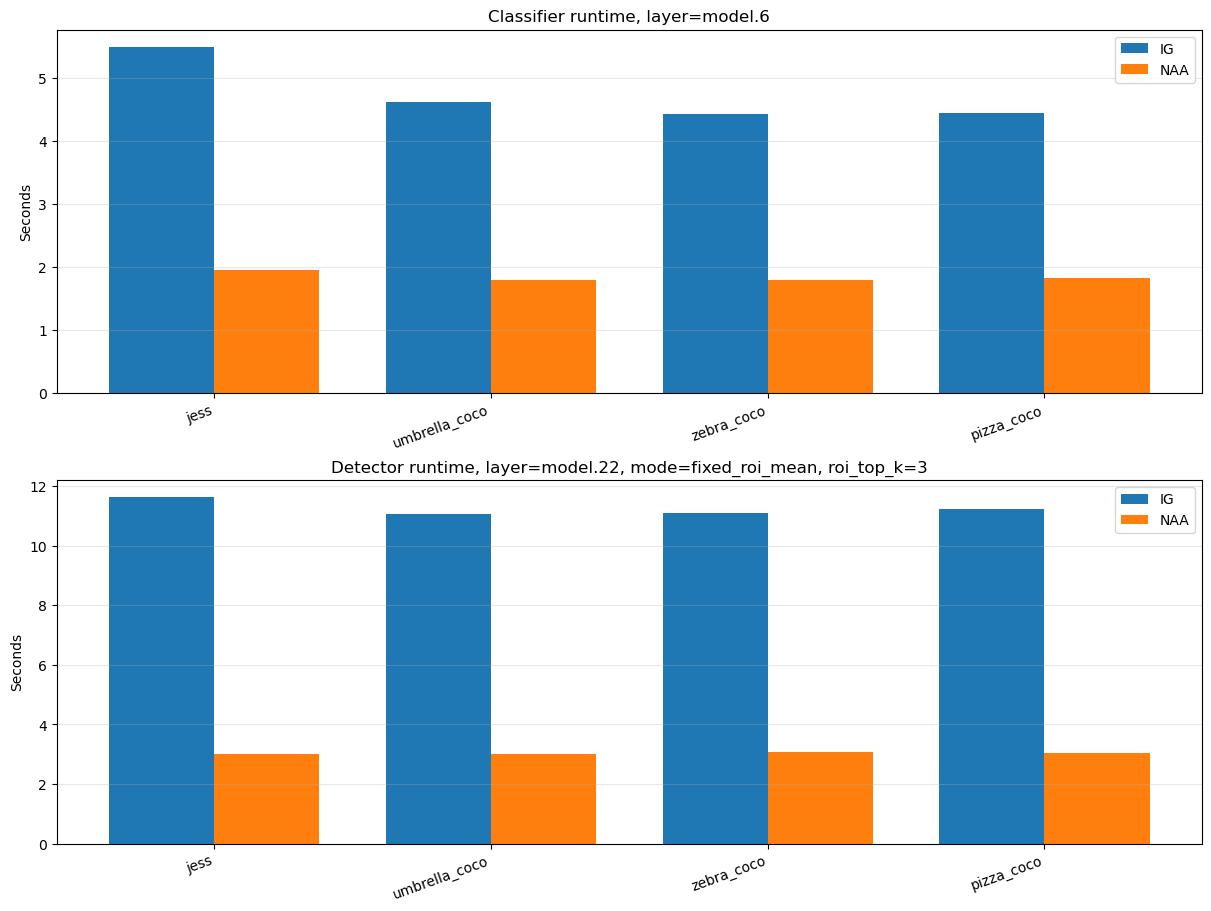

'- n_steps=128\n- repeats=1\n\n| Model type | Params | Image | IG (s) | NAA (s) |\n| --- | --- | --- | ---: | ---: |\n| classifier | layer=model.6 | jess | 5.4897 | 1.9588 |\n| classifier | layer=model.6 | umbrella_coco | 4.6114 | 1.7915 |\n| classifier | layer=model.6 | zebra_coco | 4.4220 | 1.7912 |\n| classifier | layer=model.6 | pizza_coco | 4.4400 | 1.8307 |\n| **classifier mean** | layer=model.6 | **mean** | **4.7408** | **1.8430** |\n| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | jess | 11.6249 | 3.0207 |\n| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | umbrella_coco | 11.0648 | 3.0002 |\n| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | zebra_coco | 11.1011 | 3.0673 |\n| detector | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | pizza_coco | 11.2207 | 3.0383 |\n| **detector mean** | layer=model.22, mode=fixed_roi_mean, roi_top_k=3 | **mean** | **11.2529** | **3.0316** |'

In [6]:
runtime_markdown = display_runtime_report(runtime_results)
runtime_markdown


## Oxford Pets Summary

Агрегированный benchmark для `oxford_pets`: берём до 100 картинок из директории, считаем оба метода и выводим только сводную таблицу `mean +- std` плюс графики распределения.

In [7]:
OXFORD_PETS_DIR = "oxford_pets"
OXFORD_PETS_LIMIT = 100
OXFORD_PETS_IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")


In [8]:
def list_image_paths(
    image_dir=OXFORD_PETS_DIR,
    limit=OXFORD_PETS_LIMIT,
    extensions=OXFORD_PETS_IMAGE_EXTENSIONS,
):
    directory = Path(image_dir)
    if not directory.exists():
        raise FileNotFoundError(f"Directory not found: {directory}")

    image_paths = sorted(
        str(path)
        for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in extensions
    )
    if limit is not None:
        image_paths = image_paths[:limit]
    return image_paths


def _valid_times(rows, key):
    return [row[key] for row in rows if row[key] is not None]


def _mean_std(values):
    if not values:
        return None, None
    return mean(values), stdev(values) if len(values) > 1 else 0.0


def _stats_record(values, total_count):
    mean_s, std_s = _mean_std(values)
    return {
        "values": values,
        "mean_s": mean_s,
        "std_s": std_s,
        "n_ok": len(values),
        "n_total": total_count,
    }


def _format_stats(stats):
    if stats["mean_s"] is None:
        return "n/a"
    return f"{stats['mean_s']:.4f} +- {stats['std_s']:.4f}"


def summarize_aggregate_runtime(results):
    summary = {}
    for section_name, row_label in (("classifier", "classificator"), ("detector", "detector")):
        section = results[section_name]
        total_count = len(section["rows"])
        ig_values = _valid_times(section["rows"], "ig_s")
        naa_values = _valid_times(section["rows"], "naa_s")
        summary[row_label] = {
            "IG": _stats_record(ig_values, total_count),
            "NAA": _stats_record(naa_values, total_count),
        }
    return summary


def build_aggregate_runtime_markdown(results):
    summary = results["summary"]
    lines = [
        f"- image_dir={results['image_dir']}",
        f"- n_images={len(results['image_paths'])}",
        f"- n_steps={results['classifier']['n_steps']}",
        f"- repeats={results['classifier']['repeats']}",
        f"- target_device={results['target_device']}",
        f"- cache_root={results['cache_root']}",
        f"- classificator layer={results['classifier']['layer_name']}",
        (
            f"- detector layer={results['detector']['layer_name']}, mode={results['detector']['mode']}, "
            f"roi_top_k={results['detector']['roi_top_k']}"
        ),
        (
            f"- valid runs: classificator IG {summary['classificator']['IG']['n_ok']}/{summary['classificator']['IG']['n_total']}, "
            f"NAA {summary['classificator']['NAA']['n_ok']}/{summary['classificator']['NAA']['n_total']}; "
            f"detector IG {summary['detector']['IG']['n_ok']}/{summary['detector']['IG']['n_total']}, "
            f"NAA {summary['detector']['NAA']['n_ok']}/{summary['detector']['NAA']['n_total']}"
        ),
        "",
        "|  | IG | NAA |",
        "| --- | ---: | ---: |",
        f"| classificator | {_format_stats(summary['classificator']['IG'])} | {_format_stats(summary['classificator']['NAA'])} |",
        f"| detector | {_format_stats(summary['detector']['IG'])} | {_format_stats(summary['detector']['NAA'])} |",
    ]
    return "\n".join(lines)


def _jitter_offsets(count):
    pattern = (-0.12, -0.06, 0.0, 0.06, 0.12)
    return [pattern[index % len(pattern)] for index in range(count)]


def plot_aggregate_runtime_distributions(results):
    summary = results["summary"]
    group_specs = [
        ("classificator / IG", summary["classificator"]["IG"]["values"], "#1f77b4", 1),
        ("classificator / NAA", summary["classificator"]["NAA"]["values"], "#ff7f0e", 2),
        ("detector / IG", summary["detector"]["IG"]["values"], "#1f77b4", 4),
        ("detector / NAA", summary["detector"]["NAA"]["values"], "#ff7f0e", 5),
    ]
    active_groups = [group for group in group_specs if group[1]]
    if not active_groups:
        raise ValueError("No successful timings to plot.")

    labels = [group[0] for group in active_groups]
    data = [group[1] for group in active_groups]
    colors = [group[2] for group in active_groups]
    positions = [group[3] for group in active_groups]
    means = [mean(values) for values in data]
    stds = [stdev(values) if len(values) > 1 else 0.0 for values in data]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    violin_parts = axes[0].violinplot(
        data,
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    for body, color in zip(violin_parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.35)
    if "cmedians" in violin_parts:
        violin_parts["cmedians"].set_color("black")
        violin_parts["cmedians"].set_linewidth(1.5)
    for position, values in zip(positions, data):
        xs = [position + offset for offset in _jitter_offsets(len(values))]
        axes[0].scatter(xs, values, s=10, alpha=0.2, color="black")
    axes[0].set_title("Violin plot")

    boxplot = axes[1].boxplot(
        data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
    )
    for patch, color in zip(boxplot["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
        patch.set_edgecolor(color)
    axes[1].set_title("Box plot")

    axes[2].errorbar(positions, means, yerr=stds, fmt="o", color="black", capsize=5, linewidth=1.5)
    axes[2].scatter(positions, means, s=70, c=colors)
    axes[2].set_title("Mean +- std")

    for ax in axes:
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylabel("Seconds")
        ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(f"Oxford pets runtime summary, n={len(results['image_paths'])}")
    return fig, axes


def benchmark_oxford_pets_summary(
    image_dir=OXFORD_PETS_DIR,
    limit=OXFORD_PETS_LIMIT,
    classifier_layer_name=CLASSIFIER_LAYER,
    detector_layer_name=DETECTOR_LAYER,
    detector_mode=DETECTOR_MODE,
    detector_roi_top_k=DETECTOR_ROI_TOP_K,
    n_steps=N_STEPS,
    repeats=REPEATS,
    clear_every=CLEAR_EVERY,
    cache_root=BENCHMARK_CACHE_ROOT,
    target_device=BENCHMARK_TARGET_DEVICE,
    refresh=BENCHMARK_REFRESH,
):
    image_paths = list_image_paths(image_dir=image_dir, limit=limit)
    classifier_results = benchmark_classifiers(
        image_paths=image_paths,
        layer_name=classifier_layer_name,
        n_steps=n_steps,
        repeats=repeats,
        clear_every=clear_every,
        cache_root=cache_root,
        target_device=target_device,
        refresh=refresh,
    )
    detector_results = benchmark_detectors(
        image_paths=image_paths,
        layer_name=detector_layer_name,
        mode=detector_mode,
        roi_top_k=detector_roi_top_k,
        n_steps=n_steps,
        repeats=repeats,
        clear_every=clear_every,
        cache_root=cache_root,
        target_device=target_device,
        refresh=refresh,
    )
    results = {
        "image_dir": str(image_dir),
        "image_paths": image_paths,
        "classifier": classifier_results,
        "detector": detector_results,
        "target_device": target_device,
        "cache_root": str(cache_root),
        "refresh": refresh,
    }
    results["summary"] = summarize_aggregate_runtime(results)
    return results


def display_aggregate_runtime_report(results, show_rendered_markdown=True, show_raw_markdown=True):
    markdown_text = build_aggregate_runtime_markdown(results)
    if show_rendered_markdown:
        display(Markdown(markdown_text))
    if show_raw_markdown:
        display(Markdown("```md\n" + markdown_text + "\n```"))
    plot_aggregate_runtime_distributions(results)
    plt.show()
    return markdown_text


- image_dir=oxford_pets
- n_images=100
- n_steps=128
- repeats=1
- target_device=mps
- cache_root=output/method_timing_cache
- classificator layer=model.6
- detector layer=model.22, mode=fixed_roi_mean, roi_top_k=3
- valid runs: classificator IG 100/100, NAA 100/100; detector IG 100/100, NAA 100/100

|  | IG | NAA |
| --- | ---: | ---: |
| classificator | 4.5918 +- 0.1462 | 1.8234 +- 0.1007 |
| detector | 11.8095 +- 0.6997 | 3.2270 +- 0.1626 |

```md
- image_dir=oxford_pets
- n_images=100
- n_steps=128
- repeats=1
- target_device=mps
- cache_root=output/method_timing_cache
- classificator layer=model.6
- detector layer=model.22, mode=fixed_roi_mean, roi_top_k=3
- valid runs: classificator IG 100/100, NAA 100/100; detector IG 100/100, NAA 100/100

|  | IG | NAA |
| --- | ---: | ---: |
| classificator | 4.5918 +- 0.1462 | 1.8234 +- 0.1007 |
| detector | 11.8095 +- 0.6997 | 3.2270 +- 0.1626 |
```

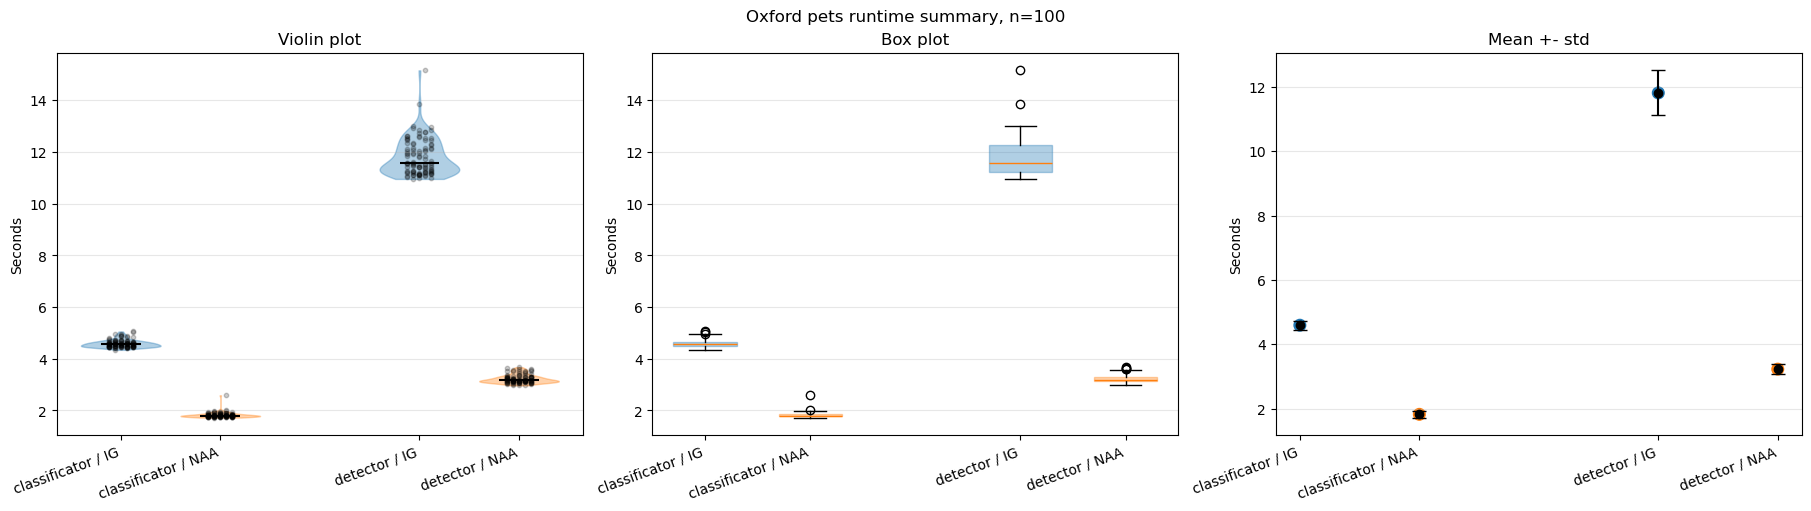

'- image_dir=oxford_pets\n- n_images=100\n- n_steps=128\n- repeats=1\n- target_device=mps\n- cache_root=output/method_timing_cache\n- classificator layer=model.6\n- detector layer=model.22, mode=fixed_roi_mean, roi_top_k=3\n- valid runs: classificator IG 100/100, NAA 100/100; detector IG 100/100, NAA 100/100\n\n|  | IG | NAA |\n| --- | ---: | ---: |\n| classificator | 4.5918 +- 0.1462 | 1.8234 +- 0.1007 |\n| detector | 11.8095 +- 0.6997 | 3.2270 +- 0.1626 |'

In [9]:
oxford_pets_results = benchmark_oxford_pets_summary(
    image_dir=OXFORD_PETS_DIR,
    limit=OXFORD_PETS_LIMIT,
    classifier_layer_name=CLASSIFIER_LAYER,
    detector_layer_name=DETECTOR_LAYER,
    detector_mode=DETECTOR_MODE,
    detector_roi_top_k=DETECTOR_ROI_TOP_K,
    n_steps=N_STEPS,
    repeats=REPEATS,
)
oxford_pets_markdown = display_aggregate_runtime_report(oxford_pets_results)
oxford_pets_markdown


In [10]:
def plot_aggregate_runtime_grouped_bars(results):
    summary = results["summary"]
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

    method_colors = {"IG": "#1f77b4", "NAA": "#ff7f0e"}
    group_centers = {"classificator": 0.0, "detector": 1.6}
    method_offsets = {"IG": -0.22, "NAA": 0.22}
    bar_width = 0.34

    ax.axvspan(-0.55, 0.55, color="#1f77b4", alpha=0.06)
    ax.axvspan(1.05, 2.15, color="#ff7f0e", alpha=0.06)
    ax.axvline(0.8, color="#999999", linestyle="--", linewidth=1, alpha=0.6)

    legend_done = set()
    for group_name in ("classificator", "detector"):
        center = group_centers[group_name]
        for method_name in ("IG", "NAA"):
            stats = summary[group_name][method_name]
            if stats["mean_s"] is None:
                continue
            x = center + method_offsets[method_name]
            label = method_name if method_name not in legend_done else None
            ax.bar(
                x,
                stats["mean_s"],
                width=bar_width,
                color=method_colors[method_name],
                alpha=0.85,
                yerr=stats["std_s"],
                capsize=7,
                error_kw={"elinewidth": 1.5, "capthick": 1.5},
                label=label,
            )
            legend_done.add(method_name)
            ax.text(x, stats["mean_s"] + stats["std_s"] + 0.08, method_name, ha="center", va="bottom", fontsize=10)

    ax.set_xticks([group_centers["classificator"], group_centers["detector"]])
    ax.set_xticklabels(["classificator", "detector"])
    ax.set_ylabel("Seconds")
    ax.set_title(f"Oxford pets runtime summary, n={len(results['image_paths'])}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="Method")
    return fig, ax


def display_aggregate_runtime_grouped_bars(results):
    plot_aggregate_runtime_grouped_bars(results)
    plt.show()


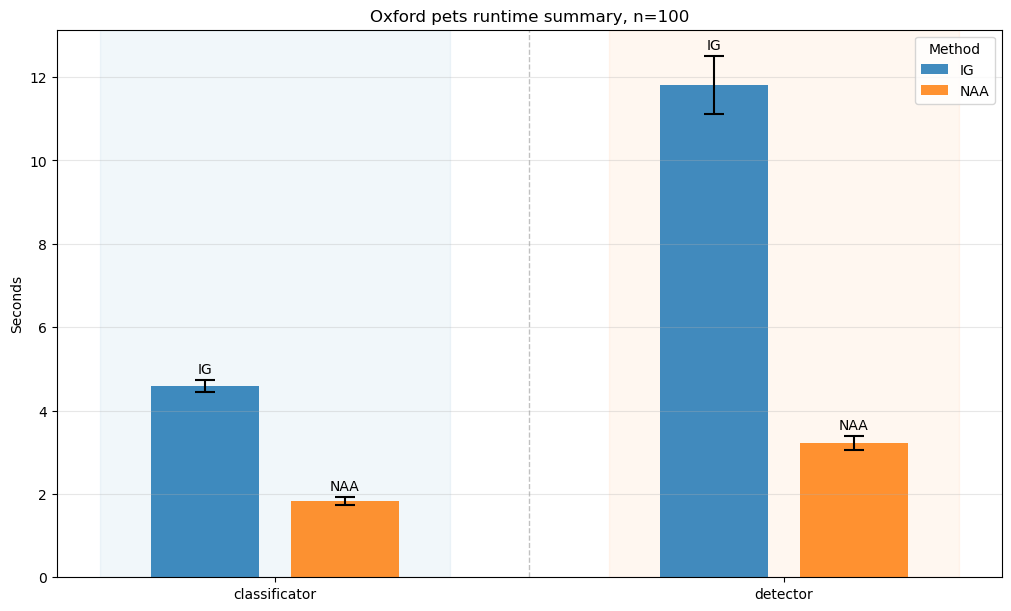

In [11]:
display_aggregate_runtime_grouped_bars(oxford_pets_results)


## Cheap-IG Timing

Ниже добавлен отдельный benchmark для `cheap-ig`. Для классификатора и детектора метод считается одинаково по идее: сначала полный cheap-scan через NAA-attribution, затем по нему выбираются top-k нейроны (`signed` или `unsigned`), и только для них считается exact segment на `[segment_start, segment_end]`. Никаких scale-fit и амортизированных вспомогательных стадий здесь нет.

Для detector target выбирается теми же правилами, что и в `IG_det.py` / `NAA_det.py`: тот же `mode`, тот же `roi_top_k`, тот же `query_rank/query_head` при их использовании. Кэширование в benchmark внешнее и одинаковое для всех методов: на диск сохраняется только итоговый timing whole-method для конкретной картинки и набора параметров.


In [12]:
from pathlib import Path
import json
import re

import numpy as np
import torch

CHEAP_IG_SOURCE_NOTEBOOK = "ImprovingAdvTransViaAttrib_covariance_approximation.ipynb"
CHEAP_IG_SOURCE_CELL_INDEX = 8
CHEAP_IG_SEGMENT_START = 0.0
CHEAP_IG_SEGMENT_END = 0.1
CHEAP_IG_SELECTION_MODE = "signed"
CHEAP_IG_SELECTION_TOP_K = 5000
CHEAP_IG_REQUIRE_MPS = True


def _trim_notebook_experiments(source_text):
    lines = source_text.splitlines()
    stop = len(lines)
    for idx, line in enumerate(lines):
        if re.match(r"^experiment_[A-Za-z0-9_]+\s*=", line):
            stop = idx
            break
    return "\n".join(lines[:stop]) + "\n"


def load_cheap_ig_namespace(
    notebook_path=CHEAP_IG_SOURCE_NOTEBOOK,
    cell_index=CHEAP_IG_SOURCE_CELL_INDEX,
):
    notebook = json.loads(Path(notebook_path).read_text())
    source = "".join(notebook["cells"][cell_index]["source"])
    namespace = {"__name__": "__cheap_ig_runtime__"}
    exec(_trim_notebook_experiments(source), namespace)
    return namespace


def _device_label(device):
    return str(device) if device is not None else "n/a"


def collect_device_report(cheap_ig_ns=None):
    report = {
        "torch.cuda.is_available": bool(torch.cuda.is_available()),
        "torch.backends.mps.is_built": bool(getattr(torch.backends.mps, "is_built", lambda: False)()),
        "torch.backends.mps.is_available": bool(getattr(torch.backends.mps, "is_available", lambda: False)()),
        "torch.mps.is_available": bool(torch.mps.is_available()) if hasattr(torch, "mps") else False,
        "IG.DEVICE": _device_label(getattr(IG, "DEVICE", None)),
        "NAA.DEVICE": _device_label(getattr(NAA, "DEVICE", None)),
        "IG_det.DEVICE": _device_label(getattr(IG_det, "DEVICE", None)),
        "NAA_det.DEVICE": _device_label(getattr(NAA_det, "DEVICE", None)),
    }
    if cheap_ig_ns is not None:
        report["cheap_ig.DEVICE"] = _device_label(cheap_ig_ns.get("DEVICE"))
        model = cheap_ig_ns.get("model")
        if model is not None:
            try:
                report["cheap_ig.model_parameter_device"] = _device_label(next(model.parameters()).device)
            except StopIteration:
                report["cheap_ig.model_parameter_device"] = "empty-model"
    return report


def _all_methods_use_mps(report):
    required = [
        "IG.DEVICE",
        "NAA.DEVICE",
        "IG_det.DEVICE",
        "NAA_det.DEVICE",
        "cheap_ig.DEVICE",
        "cheap_ig.model_parameter_device",
    ]
    return bool(report.get("torch.backends.mps.is_available")) and all(
        str(report.get(key)).startswith("mps") for key in required
    )


def build_device_report_markdown(report):
    lines = [
        "| Check | Value |",
        "| --- | --- |",
    ]
    for key, value in report.items():
        lines.append(f"| {key} | `{value}` |")
    lines.append("")
    if _all_methods_use_mps(report):
        lines.append("- active_device=`mps`")
    else:
        lines.append("- active_device is not fully `mps` in this kernel")
    lines.append(f"- benchmark_target_device=`{BENCHMARK_TARGET_DEVICE}`")
    lines.append(f"- benchmark_cache_root=`{BENCHMARK_CACHE_ROOT}`")
    lines.append("- benchmark cache is external: only final whole-method timings are stored and reused")
    return "\n".join(lines)


if "CHEAP_IG_NS" not in globals():
    CHEAP_IG_NS = load_cheap_ig_namespace()

cheap_ig_device_report = collect_device_report(CHEAP_IG_NS)
cheap_ig_device_markdown = build_device_report_markdown(cheap_ig_device_report)
display(Markdown(cheap_ig_device_markdown))
cheap_ig_device_report


| Check | Value |
| --- | --- |
| torch.cuda.is_available | `False` |
| torch.backends.mps.is_built | `True` |
| torch.backends.mps.is_available | `True` |
| torch.mps.is_available | `True` |
| IG.DEVICE | `mps` |
| NAA.DEVICE | `mps` |
| IG_det.DEVICE | `mps` |
| NAA_det.DEVICE | `mps` |
| cheap_ig.DEVICE | `mps` |
| cheap_ig.model_parameter_device | `mps:0` |

- active_device=`mps`
- benchmark_target_device=`mps`
- benchmark_cache_root=`output/method_timing_cache`
- benchmark cache is external: only final whole-method timings are stored and reused

{'torch.cuda.is_available': False,
 'torch.backends.mps.is_built': True,
 'torch.backends.mps.is_available': True,
 'torch.mps.is_available': True,
 'IG.DEVICE': 'mps',
 'NAA.DEVICE': 'mps',
 'IG_det.DEVICE': 'mps',
 'NAA_det.DEVICE': 'mps',
 'cheap_ig.DEVICE': 'mps',
 'cheap_ig.model_parameter_device': 'mps:0'}

In [13]:
def _clear_cheap_ig_backend_cache(cheap_ig_ns):
    clear_fn = cheap_ig_ns.get("clear_backend_cache")
    if clear_fn is not None:
        clear_fn()


def _cheap_ig_alpha_grid(n_steps):
    return np.linspace(1.0 / n_steps, 1.0, int(n_steps), dtype=np.float64)


def _cheap_ig_segment_index_mask(alphas, start, end):
    alphas = np.asarray(alphas, dtype=np.float64)
    if end < 1.0:
        return np.nonzero((alphas >= start) & (alphas < end))[0]
    return np.nonzero((alphas >= start) & (alphas <= end))[0]


def _cheap_ig_selection_mask(scores, selection_mode, selection_top_k):
    scores = np.asarray(scores, dtype=np.float64)
    mask = np.zeros(scores.shape[0], dtype=bool)
    if selection_top_k <= 0 or scores.size == 0:
        return mask

    selection_top_k = int(min(selection_top_k, scores.size))

    if selection_mode == "signed":
        pos_idx = np.flatnonzero(scores > 0)
        neg_idx = np.flatnonzero(scores < 0)

        if pos_idx.size > 0:
            k_pos = min(selection_top_k, pos_idx.size)
            if k_pos >= pos_idx.size:
                mask[pos_idx] = True
            else:
                chosen_pos = np.argpartition(scores[pos_idx], pos_idx.size - k_pos)[-k_pos:]
                mask[pos_idx[chosen_pos]] = True

        if neg_idx.size > 0:
            k_neg = min(selection_top_k, neg_idx.size)
            if k_neg >= neg_idx.size:
                mask[neg_idx] = True
            else:
                chosen_neg = np.argpartition(np.abs(scores[neg_idx]), neg_idx.size - k_neg)[-k_neg:]
                mask[neg_idx[chosen_neg]] = True
    elif selection_mode == "unsigned":
        if selection_top_k >= scores.size:
            mask[:] = True
        else:
            chosen = np.argpartition(np.abs(scores), scores.size - selection_top_k)[-selection_top_k:]
            mask[chosen] = True
    else:
        raise ValueError(f"Unsupported selection_mode: {selection_mode}")

    return mask


def _validate_cheap_ig_segment(n_steps, segment_start, segment_end):
    alphas = _cheap_ig_alpha_grid(n_steps)
    segment_idx = _cheap_ig_segment_index_mask(alphas, segment_start, segment_end)
    if len(segment_idx) == 0:
        raise ValueError(
            f"alpha segment [{segment_start}, {segment_end}] has no samples for n_steps={n_steps}; "
            "increase n_steps or widen the segment"
        )


def _to_part_tuple(obj):
    if torch.is_tensor(obj):
        return (obj,)
    if isinstance(obj, (list, tuple)):
        tensors = tuple(part for part in obj if torch.is_tensor(part))
        if tensors:
            return tensors
    raise TypeError(f"Expected tensor/list/tuple, got {type(obj).__name__}")


def _flatten_part_arrays(parts):
    arrays = [part.detach().cpu().reshape(-1).numpy().astype(np.float64) for part in parts]
    if not arrays:
        return np.empty(0, dtype=np.float64), []
    return np.concatenate(arrays, axis=0), [arr.size for arr in arrays]


def _split_flat_mask(flat_mask, part_sizes):
    masks = []
    start = 0
    for size in part_sizes:
        stop = start + int(size)
        masks.append(np.asarray(flat_mask[start:stop], dtype=bool))
        start = stop
    return masks


def _run_classifier_cheap_ig_once(
    *,
    cheap_ig_ns,
    image_path,
    layer_name,
    n_steps,
    segment_start,
    segment_end,
    selection_mode,
    selection_top_k,
    clear_every,
):
    image_path = Path(image_path)
    torch_mod = cheap_ig_ns["torch"]
    jvp_fn = cheap_ig_ns["jvp"]
    model = cheap_ig_ns["model"]
    class_names = cheap_ig_ns["class_names"]
    load_image = cheap_ig_ns["load_image"]
    black_baseline_like = cheap_ig_ns["black_baseline_like"]
    LayerHook = cheap_ig_ns["LayerHook"]
    forward_with_layer = cheap_ig_ns["_forward_with_layer"]
    flatten_tensor = cheap_ig_ns["_flatten_tensor"]
    split_classifier_output = cheap_ig_ns["split_classifier_output"]
    clear_backend_cache = cheap_ig_ns.get("clear_backend_cache")

    x, _ = load_image(str(image_path))
    x0 = black_baseline_like(x)
    delta_x = (x - x0).contiguous()
    alphas = _cheap_ig_alpha_grid(n_steps)
    segment_idx = _cheap_ig_segment_index_mask(alphas, segment_start, segment_end)
    segment_index_set = {int(idx) for idx in np.asarray(segment_idx, dtype=np.int64).tolist()}

    hook = LayerHook(model, layer_name)
    try:
        with torch_mod.no_grad():
            out, act_x = forward_with_layer(model, hook, x)
            _, logits = split_classifier_output(out)
            target_class = int(logits[0].argmax().item())
            target_name = class_names[target_class]
            fx = float(logits[0, target_class].item())

            out_x0, act_x0 = forward_with_layer(model, hook, x0)
            _, logits_x0 = split_classifier_output(out_x0)
            fx0 = float(logits_x0[0, target_class].item())
            fx_delta = fx - fx0

        delta_y = flatten_tensor((act_x - act_x0).detach()).astype(np.float64, copy=False)

        sum_a_full = None
        sum_ab_segment = None
        segment_steps = 0

        def layer_activation(x_in):
            _, act = forward_with_layer(model, hook, x_in)
            return act

        for step_idx, alpha in enumerate(alphas):
            x_alpha = (x0 + float(alpha) * delta_x).contiguous().detach().requires_grad_(True)

            out, act = forward_with_layer(model, hook, x_alpha)
            _, logits = split_classifier_output(out)
            score = logits[0, target_class]
            grad_y = torch_mod.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]
            grad_flat = flatten_tensor(grad_y.detach()).astype(np.float64, copy=False)

            if sum_a_full is None:
                sum_a_full = np.zeros_like(grad_flat, dtype=np.float64)
                sum_ab_segment = np.zeros_like(grad_flat, dtype=np.float64)

            sum_a_full += grad_flat

            if step_idx in segment_index_set:
                hook.clear()
                _, jvp_out = jvp_fn(layer_activation, (x_alpha,), (delta_x,))
                dir_flat = flatten_tensor(jvp_out.detach()).astype(np.float64, copy=False)
                sum_ab_segment += grad_flat * dir_flat
                segment_steps += 1
                del jvp_out, dir_flat

            del x_alpha, out, act, logits, score, grad_y, grad_flat
            hook.clear()

            if clear_every > 0 and ((step_idx + 1) % clear_every == 0) and clear_backend_cache is not None:
                clear_backend_cache()

        if sum_a_full is None or sum_ab_segment is None or segment_steps == 0:
            raise RuntimeError("cheap-ig failed to accumulate classifier attribution statistics")

        approx_naa_vector = sum_a_full / len(alphas) * delta_y
        exact_segment_vector = sum_ab_segment / segment_steps
        sparse_mask = _cheap_ig_selection_mask(approx_naa_vector, selection_mode, selection_top_k)
        cheap_ig_vector = np.zeros_like(exact_segment_vector)
        cheap_ig_vector[sparse_mask] = exact_segment_vector[sparse_mask]
        cheap_ig_sum = float(cheap_ig_vector.sum())

        return {
            "image_path": str(image_path),
            "image_label": image_path.stem,
            "target_class": target_class,
            "target_name": str(target_name),
            "fx_delta": float(fx_delta),
            "vector_sum": cheap_ig_sum,
            "abs_error": float(abs(fx_delta - cheap_ig_sum)),
            "selected_neurons": int(sparse_mask.sum()),
            "segment_steps": int(segment_steps),
        }
    finally:
        hook.remove()
        if clear_backend_cache is not None:
            clear_backend_cache()


def benchmark_cheap_ig_classifier_summary(
    image_dir=OXFORD_PETS_DIR,
    limit=OXFORD_PETS_LIMIT,
    layer_name=CLASSIFIER_LAYER,
    n_steps=N_STEPS,
    segment_start=CHEAP_IG_SEGMENT_START,
    segment_end=CHEAP_IG_SEGMENT_END,
    selection_mode=CHEAP_IG_SELECTION_MODE,
    selection_top_k=CHEAP_IG_SELECTION_TOP_K,
    repeats=REPEATS,
    clear_every=CLEAR_EVERY,
    require_mps=CHEAP_IG_REQUIRE_MPS,
    cache_root=BENCHMARK_CACHE_ROOT,
    target_device=BENCHMARK_TARGET_DEVICE,
    refresh=BENCHMARK_REFRESH,
    cheap_ig_ns=None,
):
    cheap_ig_ns = cheap_ig_ns or CHEAP_IG_NS
    effective_target_device = "mps" if require_mps else target_device
    current_device = _device_label(cheap_ig_ns.get("DEVICE"))
    image_paths = list_image_paths(image_dir=image_dir, limit=limit)
    _validate_cheap_ig_segment(n_steps, segment_start, segment_end)

    def clear_all():
        _clear_all_caches()
        _clear_cheap_ig_backend_cache(cheap_ig_ns)

    rows = []
    for image_path in image_paths:
        image_key = image_signature(image_path)
        timing = time_call_cached(
            cache_root=cache_root,
            namespace="classifier_cheap_ig",
            config={
                "method_family": "classifier",
                "method": "cheap-ig",
                "image": image_key,
                "layer_name": layer_name,
                "n_steps": int(n_steps),
                "segment_start": float(segment_start),
                "segment_end": float(segment_end),
                "selection_mode": selection_mode,
                "selection_top_k": int(selection_top_k),
                "clear_every": int(clear_every),
                "target_device": effective_target_device,
            },
            label=f"{image_label(image_path)}_cheap_ig",
            fn=lambda image_path=image_path: _run_classifier_cheap_ig_once(
                cheap_ig_ns=cheap_ig_ns,
                image_path=image_path,
                layer_name=layer_name,
                n_steps=n_steps,
                segment_start=segment_start,
                segment_end=segment_end,
                selection_mode=selection_mode,
                selection_top_k=selection_top_k,
                clear_every=clear_every,
            ),
            repeats=repeats,
            refresh=refresh,
            clear_before=clear_all,
            required_device=effective_target_device,
            current_device=current_device,
        )
        result = timing["result"] or {}
        rows.append(
            {
                "image_path": image_path,
                "image_label": image_label(image_path),
                "time_s": timing["mean_s"],
                "runs": timing["runs"],
                "error": timing["error"],
                "cache_path": timing["cache_path"],
                "from_cache": timing["from_cache"],
                "abs_error": result.get("abs_error"),
                "fx_delta": result.get("fx_delta"),
                "vector_sum": result.get("vector_sum"),
                "selected_neurons": result.get("selected_neurons"),
                "target_class": result.get("target_class"),
                "target_name": result.get("target_name"),
                "segment_steps": result.get("segment_steps"),
            }
        )

    results = {
        "kind": "classifier_cheap_ig",
        "image_dir": str(image_dir),
        "image_paths": image_paths,
        "layer_name": layer_name,
        "n_steps": n_steps,
        "segment_start": segment_start,
        "segment_end": segment_end,
        "selection_mode": selection_mode,
        "selection_top_k": selection_top_k,
        "repeats": repeats,
        "target_device": effective_target_device,
        "cache_root": str(cache_root),
        "actual_device": current_device,
        "rows": rows,
        "device_report": collect_device_report(cheap_ig_ns),
    }
    results["summary"] = _stats_record(_valid_times(rows, "time_s"), len(rows))
    results["abs_error_summary"] = _stats_record(_valid_times(rows, "abs_error"), len(rows))
    results["selected_neurons_summary"] = _stats_record(_valid_times(rows, "selected_neurons"), len(rows))
    return results


def _resolve_detector_target_spec(raw_output, mode, roi_top_k, query_rank, query_head, bbox_iou_threshold):
    if mode == "fixed_query":
        return IG_det.pick_fixed_query_target(
            raw_output,
            num_classes=len(IG_det.class_names),
            query_rank=query_rank,
            query_head=query_head,
            bbox_iou_threshold=bbox_iou_threshold,
        )
    return IG_det.pick_fixed_roi_target(
        raw_output,
        num_classes=len(IG_det.class_names),
        roi_mode=mode,
        roi_top_k=roi_top_k,
        query_rank=query_rank,
        query_head=query_head,
        bbox_iou_threshold=bbox_iou_threshold,
    )


def _run_detector_cheap_ig_once(
    *,
    image_path,
    layer_name,
    mode,
    roi_top_k,
    query_rank,
    query_head,
    bbox_iou_threshold,
    n_steps,
    segment_start,
    segment_end,
    selection_mode,
    selection_top_k,
    clear_every,
):
    if mode not in {"fixed_query", "fixed_roi_lse", "fixed_roi_logmeanexp", "fixed_roi_mean"}:
        raise ValueError(f"Unsupported detector cheap-ig mode: {mode}")

    image_path = Path(image_path)
    resolved_layer_names = IG_det.LAYER_GROUPS[layer_name] if layer_name in IG_det.LAYER_GROUPS else (layer_name,)
    x, _, _ = IG_det.load_image(str(image_path))
    x0 = IG_det.black_baseline_like(x)
    delta_x = (x - x0).contiguous()
    alphas = _cheap_ig_alpha_grid(n_steps)
    segment_idx = _cheap_ig_segment_index_mask(alphas, segment_start, segment_end)
    segment_index_set = {int(idx) for idx in np.asarray(segment_idx, dtype=np.int64).tolist()}
    bbox_iou_threshold = IG_det.BBOX_RANK_IOU_THRESHOLD if bbox_iou_threshold is None else float(bbox_iou_threshold)

    hook = IG_det.LayerHook(IG_det.model, resolved_layer_names)
    try:
        def forward_with_layer(x_in):
            hook.clear()
            out = IG_det.model(x_in)
            act = IG_det.unwrap_tensor(hook.get())
            return out, act

        with torch.no_grad():
            raw_x, act_x = forward_with_layer(x)
            target_spec = _resolve_detector_target_spec(
                raw_x,
                mode=mode,
                roi_top_k=roi_top_k,
                query_rank=query_rank,
                query_head=query_head,
                bbox_iou_threshold=bbox_iou_threshold,
            )
            fx = float(IG_det.detection_scalar_target(raw_x, target_spec, len(IG_det.class_names)).item())

            raw_x0, act_x0 = forward_with_layer(x0)
            fx0 = float(IG_det.detection_scalar_target(raw_x0, target_spec, len(IG_det.class_names)).item())
            fx_delta = fx - fx0

        act_x_parts = _to_part_tuple(act_x)
        act_x0_parts = _to_part_tuple(act_x0)
        delta_y_parts = tuple((ax - ax0).detach() for ax, ax0 in zip(act_x_parts, act_x0_parts))
        ia_accum_parts = tuple(torch.zeros_like(part) for part in delta_y_parts)

        for m in range(1, n_steps + 1):
            alpha = m / n_steps
            x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

            raw_out, act = forward_with_layer(x_alpha)
            score = IG_det.detection_scalar_target(raw_out, target_spec, len(IG_det.class_names))
            act_parts = _to_part_tuple(act)
            grad_parts = torch.autograd.grad(
                score,
                act_parts,
                retain_graph=False,
                create_graph=False,
                allow_unused=True,
            )
            grad_parts = tuple(torch.zeros_like(a) if g is None else g for a, g in zip(act_parts, grad_parts))
            ia_accum_parts = tuple(acc + g.detach() for acc, g in zip(ia_accum_parts, grad_parts))

            del x_alpha, raw_out, act, score, act_parts, grad_parts
            hook.clear()

            if clear_every > 0 and (m % clear_every == 0):
                IG_det.clear_backend_cache()

        approx_parts = tuple(dy * (acc / n_steps) for dy, acc in zip(delta_y_parts, ia_accum_parts))
        approx_vector, part_sizes = _flatten_part_arrays(approx_parts)
        flat_mask = _cheap_ig_selection_mask(approx_vector, selection_mode, selection_top_k)
        part_masks = _split_flat_mask(flat_mask, part_sizes)
        mask_flags = [bool(mask.any()) for mask in part_masks]
        mask_tensors = [torch.from_numpy(mask).to(x.device) if has_any else None for mask, has_any in zip(part_masks, mask_flags)]

        selected_sum_accum = 0.0
        segment_steps = 0

        def layer_activation(x_in):
            _, act = forward_with_layer(x_in)
            return act

        for step_idx, alpha in enumerate(alphas):
            if step_idx not in segment_index_set:
                continue

            x_alpha = (x0 + float(alpha) * delta_x).contiguous().detach().requires_grad_(True)
            raw_out, act = forward_with_layer(x_alpha)
            score = IG_det.detection_scalar_target(raw_out, target_spec, len(IG_det.class_names))
            act_parts = _to_part_tuple(act)
            grad_parts = torch.autograd.grad(
                score,
                act_parts,
                retain_graph=False,
                create_graph=False,
                allow_unused=True,
            )
            grad_parts = tuple(torch.zeros_like(a) if g is None else g for a, g in zip(act_parts, grad_parts))

            hook.clear()
            _, jvp_out = IG_det.jvp(layer_activation, (x_alpha,), (delta_x,))
            dir_parts = _to_part_tuple(jvp_out)

            for grad_part, dir_part, has_any, part_mask in zip(grad_parts, dir_parts, mask_flags, mask_tensors):
                if not has_any:
                    continue
                part_values = (grad_part.detach() * dir_part.detach()).reshape(-1)
                selected_sum_accum += float(part_values[part_mask].sum().item())

            segment_steps += 1
            del x_alpha, raw_out, act, score, act_parts, grad_parts, jvp_out, dir_parts
            hook.clear()

            if clear_every > 0 and (segment_steps % clear_every == 0):
                IG_det.clear_backend_cache()

        if segment_steps == 0:
            raise RuntimeError("cheap-ig failed to accumulate detector segment attribution")

        cheap_ig_sum = selected_sum_accum / segment_steps
        target_class = int(target_spec["class_index"])
        target_name = IG_det.class_names[target_class]
        roi_query_count = int(target_spec["roi_mask"].sum().item()) if "roi_mask" in target_spec else None

        return {
            "image_path": str(image_path),
            "image_label": image_path.stem,
            "target_class": target_class,
            "target_name": str(target_name),
            "fx_delta": float(fx_delta),
            "vector_sum": float(cheap_ig_sum),
            "abs_error": float(abs(fx_delta - cheap_ig_sum)),
            "selected_neurons": int(flat_mask.sum()),
            "segment_steps": int(segment_steps),
            "roi_query_count": roi_query_count,
        }
    finally:
        hook.remove()
        IG_det.clear_backend_cache()


def benchmark_cheap_ig_detector_summary(
    image_dir=OXFORD_PETS_DIR,
    limit=OXFORD_PETS_LIMIT,
    layer_name=DETECTOR_LAYER,
    mode=DETECTOR_MODE,
    roi_top_k=DETECTOR_ROI_TOP_K,
    query_rank=None,
    query_head=None,
    bbox_iou_threshold=None,
    n_steps=N_STEPS,
    segment_start=CHEAP_IG_SEGMENT_START,
    segment_end=CHEAP_IG_SEGMENT_END,
    selection_mode=CHEAP_IG_SELECTION_MODE,
    selection_top_k=CHEAP_IG_SELECTION_TOP_K,
    repeats=REPEATS,
    clear_every=CLEAR_EVERY,
    require_mps=CHEAP_IG_REQUIRE_MPS,
    cache_root=BENCHMARK_CACHE_ROOT,
    target_device=BENCHMARK_TARGET_DEVICE,
    refresh=BENCHMARK_REFRESH,
):
    effective_target_device = "mps" if require_mps else target_device
    current_device = _device_label(getattr(IG_det, "DEVICE", None))
    image_paths = list_image_paths(image_dir=image_dir, limit=limit)
    _validate_cheap_ig_segment(n_steps, segment_start, segment_end)
    bbox_iou_threshold = IG_det.BBOX_RANK_IOU_THRESHOLD if bbox_iou_threshold is None else float(bbox_iou_threshold)

    def clear_all():
        _clear_all_caches()
        IG_det.clear_backend_cache()

    rows = []
    for image_path in image_paths:
        image_key = image_signature(image_path)
        timing = time_call_cached(
            cache_root=cache_root,
            namespace="detector_cheap_ig",
            config={
                "method_family": "detector",
                "method": "cheap-ig",
                "image": image_key,
                "layer_name": layer_name,
                "mode": mode,
                "roi_top_k": int(roi_top_k),
                "query_rank": query_rank,
                "query_head": query_head,
                "bbox_iou_threshold": bbox_iou_threshold,
                "n_steps": int(n_steps),
                "segment_start": float(segment_start),
                "segment_end": float(segment_end),
                "selection_mode": selection_mode,
                "selection_top_k": int(selection_top_k),
                "clear_every": int(clear_every),
                "target_device": effective_target_device,
            },
            label=f"{image_label(image_path)}_cheap_ig_det",
            fn=lambda image_path=image_path: _run_detector_cheap_ig_once(
                image_path=image_path,
                layer_name=layer_name,
                mode=mode,
                roi_top_k=roi_top_k,
                query_rank=query_rank,
                query_head=query_head,
                bbox_iou_threshold=bbox_iou_threshold,
                n_steps=n_steps,
                segment_start=segment_start,
                segment_end=segment_end,
                selection_mode=selection_mode,
                selection_top_k=selection_top_k,
                clear_every=clear_every,
            ),
            repeats=repeats,
            refresh=refresh,
            clear_before=clear_all,
            required_device=effective_target_device,
            current_device=current_device,
        )
        result = timing["result"] or {}
        rows.append(
            {
                "image_path": image_path,
                "image_label": image_label(image_path),
                "time_s": timing["mean_s"],
                "runs": timing["runs"],
                "error": timing["error"],
                "cache_path": timing["cache_path"],
                "from_cache": timing["from_cache"],
                "abs_error": result.get("abs_error"),
                "fx_delta": result.get("fx_delta"),
                "vector_sum": result.get("vector_sum"),
                "selected_neurons": result.get("selected_neurons"),
                "target_class": result.get("target_class"),
                "target_name": result.get("target_name"),
                "segment_steps": result.get("segment_steps"),
                "roi_query_count": result.get("roi_query_count"),
            }
        )

    results = {
        "kind": "detector_cheap_ig",
        "image_dir": str(image_dir),
        "image_paths": image_paths,
        "layer_name": layer_name,
        "mode": mode,
        "roi_top_k": roi_top_k,
        "query_rank": query_rank,
        "query_head": query_head,
        "bbox_iou_threshold": bbox_iou_threshold,
        "n_steps": n_steps,
        "segment_start": segment_start,
        "segment_end": segment_end,
        "selection_mode": selection_mode,
        "selection_top_k": selection_top_k,
        "repeats": repeats,
        "target_device": effective_target_device,
        "cache_root": str(cache_root),
        "actual_device": current_device,
        "rows": rows,
    }
    results["summary"] = _stats_record(_valid_times(rows, "time_s"), len(rows))
    results["abs_error_summary"] = _stats_record(_valid_times(rows, "abs_error"), len(rows))
    results["selected_neurons_summary"] = _stats_record(_valid_times(rows, "selected_neurons"), len(rows))
    results["roi_query_count_summary"] = _stats_record(_valid_times(rows, "roi_query_count"), len(rows))
    return results


def build_classifier_cheap_ig_runtime_markdown(results):
    runtime_summary = results["summary"]
    abs_error_summary = results["abs_error_summary"]
    selected_summary = results["selected_neurons_summary"]
    lines = [
        f"- image_dir={results['image_dir']}",
        f"- n_images={len(results['image_paths'])}",
        f"- layer={results['layer_name']}",
        f"- n_steps={results['n_steps']}",
        f"- alpha_segment=[{results['segment_start']}, {results['segment_end']}]",
        f"- selection_mode={results['selection_mode']}",
        f"- selection_top_k={results['selection_top_k']}",
        f"- target_device={results['target_device']}",
        f"- cache_root={results['cache_root']}",
        (
            f"- valid runs: cheap-ig {runtime_summary['n_ok']}/{runtime_summary['n_total']}, "
            f"abs_error {abs_error_summary['n_ok']}/{abs_error_summary['n_total']}"
        ),
        "",
        "| Metric | Value |",
        "| --- | ---: |",
        f"| runtime | {_format_stats(runtime_summary)} |",
        f"| abs_error | {_format_stats(abs_error_summary)} |",
        f"| selected_neurons | {_format_stats(selected_summary)} |",
    ]
    return "\n".join(lines)


def build_detector_cheap_ig_runtime_markdown(results):
    runtime_summary = results["summary"]
    abs_error_summary = results["abs_error_summary"]
    selected_summary = results["selected_neurons_summary"]
    roi_summary = results["roi_query_count_summary"]
    lines = [
        f"- image_dir={results['image_dir']}",
        f"- n_images={len(results['image_paths'])}",
        f"- layer={results['layer_name']}",
        f"- mode={results['mode']}",
        f"- roi_top_k={results['roi_top_k']}",
        f"- query_rank={results['query_rank']}",
        f"- query_head={results['query_head']}",
        f"- bbox_iou_threshold={results['bbox_iou_threshold']}",
        f"- n_steps={results['n_steps']}",
        f"- alpha_segment=[{results['segment_start']}, {results['segment_end']}]",
        f"- selection_mode={results['selection_mode']}",
        f"- selection_top_k={results['selection_top_k']}",
        f"- target_device={results['target_device']}",
        f"- cache_root={results['cache_root']}",
        (
            f"- valid runs: cheap-ig {runtime_summary['n_ok']}/{runtime_summary['n_total']}, "
            f"abs_error {abs_error_summary['n_ok']}/{abs_error_summary['n_total']}"
        ),
        "",
        "| Metric | Value |",
        "| --- | ---: |",
        f"| runtime | {_format_stats(runtime_summary)} |",
        f"| abs_error | {_format_stats(abs_error_summary)} |",
        f"| selected_neurons | {_format_stats(selected_summary)} |",
        f"| roi_query_count | {_format_stats(roi_summary)} |",
    ]
    return "\n".join(lines)


def build_aggregate_runtime_markdown_with_cheap_ig(
    base_results,
    classifier_cheap_ig_results,
    detector_cheap_ig_results,
):
    classifier_summary = base_results["summary"]["classificator"]
    detector_summary = base_results["summary"]["detector"]
    classifier_cheap_summary = classifier_cheap_ig_results["summary"]
    detector_cheap_summary = detector_cheap_ig_results["summary"]
    cheap_ig_label = (
        f"cheap-ig [{classifier_cheap_ig_results['segment_start']},{classifier_cheap_ig_results['segment_end']}], "
        f"{classifier_cheap_ig_results['selection_mode']} {classifier_cheap_ig_results['selection_top_k']}"
    )

    lines = [
        f"- image_dir={base_results['image_dir']}",
        f"- n_images={len(base_results['image_paths'])}",
        f"- n_steps={base_results['classifier']['n_steps']}",
        f"- target_device={base_results['target_device']}",
        f"- cache_root={base_results['cache_root']}",
        f"- cheap_ig_classifier_alpha_segment=[{classifier_cheap_ig_results['segment_start']}, {classifier_cheap_ig_results['segment_end']}]",
        f"- cheap_ig_detector_mode={detector_cheap_ig_results['mode']}, roi_top_k={detector_cheap_ig_results['roi_top_k']}",
        f"- cheap_ig_selection={classifier_cheap_ig_results['selection_mode']}, top_k={classifier_cheap_ig_results['selection_top_k']}",
        "- benchmark cache is external only and not included in method runtime",
        "",
        f"| Model type | IG | NAA | {cheap_ig_label} |",
        "| --- | ---: | ---: | ---: |",
        (
            f"| classificator | {_format_stats(classifier_summary['IG'])} | "
            f"{_format_stats(classifier_summary['NAA'])} | {_format_stats(classifier_cheap_summary)} |"
        ),
        (
            f"| detector | {_format_stats(detector_summary['IG'])} | "
            f"{_format_stats(detector_summary['NAA'])} | {_format_stats(detector_cheap_summary)} |"
        ),
    ]
    return "\n".join(lines)


def plot_aggregate_runtime_grouped_bars_with_cheap_ig(
    base_results,
    classifier_cheap_ig_results,
    detector_cheap_ig_results,
):
    classifier_summary = base_results["summary"]["classificator"]
    detector_summary = base_results["summary"]["detector"]
    classifier_cheap_summary = classifier_cheap_ig_results["summary"]
    detector_cheap_summary = detector_cheap_ig_results["summary"]

    fig, ax = plt.subplots(figsize=(11.5, 6), constrained_layout=True)

    method_colors = {"IG": "#1f77b4", "NAA": "#ff7f0e", "cheap-ig": "#2ca02c"}
    classifier_positions = {"IG": -0.28, "NAA": 0.00, "cheap-ig": 0.28}
    detector_positions = {"IG": 1.32, "NAA": 1.60, "cheap-ig": 1.88}
    bar_width = 0.22

    ax.axvspan(-0.62, 0.62, color="#1f77b4", alpha=0.05)
    ax.axvspan(1.02, 2.18, color="#ff7f0e", alpha=0.05)
    ax.axvline(0.82, color="#999999", linestyle="--", linewidth=1, alpha=0.6)

    legend_done = set()
    classifier_methods = {
        "IG": classifier_summary["IG"],
        "NAA": classifier_summary["NAA"],
        "cheap-ig": classifier_cheap_summary,
    }
    for method_name, stats in classifier_methods.items():
        if stats["mean_s"] is None:
            continue
        x = classifier_positions[method_name]
        label = method_name if method_name not in legend_done else None
        ax.bar(
            x,
            stats["mean_s"],
            width=bar_width,
            color=method_colors[method_name],
            alpha=0.88,
            yerr=stats["std_s"],
            capsize=7,
            error_kw={"elinewidth": 1.5, "capthick": 1.5},
            label=label,
        )
        legend_done.add(method_name)
        ax.text(x, stats["mean_s"] + stats["std_s"] + 0.08, method_name, ha="center", va="bottom", fontsize=10)

    detector_methods = {
        "IG": detector_summary["IG"],
        "NAA": detector_summary["NAA"],
        "cheap-ig": detector_cheap_summary,
    }
    for method_name, stats in detector_methods.items():
        if stats["mean_s"] is None:
            continue
        x = detector_positions[method_name]
        label = method_name if method_name not in legend_done else None
        ax.bar(
            x,
            stats["mean_s"],
            width=bar_width,
            color=method_colors[method_name],
            alpha=0.88,
            yerr=stats["std_s"],
            capsize=7,
            error_kw={"elinewidth": 1.5, "capthick": 1.5},
            label=label,
        )
        legend_done.add(method_name)
        ax.text(x, stats["mean_s"] + stats["std_s"] + 0.08, method_name, ha="center", va="bottom", fontsize=10)

    ax.set_xticks([0.0, 1.60])
    ax.set_xticklabels(["classificator", "detector"])
    ax.set_ylabel("Seconds")
    ax.set_title(f"Oxford pets runtime summary with cheap-ig, n={len(base_results['image_paths'])}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="Method")
    return fig, ax


def display_cheap_ig_runtime_report(
    base_results,
    classifier_cheap_ig_results,
    detector_cheap_ig_results,
    show_rendered_markdown=True,
    show_raw_markdown=True,
):
    aggregate_markdown = build_aggregate_runtime_markdown_with_cheap_ig(
        base_results,
        classifier_cheap_ig_results,
        detector_cheap_ig_results,
    )
    classifier_markdown = build_classifier_cheap_ig_runtime_markdown(classifier_cheap_ig_results)
    detector_markdown = build_detector_cheap_ig_runtime_markdown(detector_cheap_ig_results)

    if show_rendered_markdown:
        display(Markdown(aggregate_markdown))
        display(Markdown(classifier_markdown))
        display(Markdown(detector_markdown))

    if show_raw_markdown:
        display(Markdown("```md\n" + aggregate_markdown + "\n```"))
        display(Markdown("```md\n" + classifier_markdown + "\n```"))
        display(Markdown("```md\n" + detector_markdown + "\n```"))

    plot_aggregate_runtime_grouped_bars_with_cheap_ig(
        base_results,
        classifier_cheap_ig_results,
        detector_cheap_ig_results,
    )
    plt.show()

    return {
        "aggregate_markdown": aggregate_markdown,
        "classifier_cheap_ig_markdown": classifier_markdown,
        "detector_cheap_ig_markdown": detector_markdown,
    }


- image_dir=oxford_pets
- n_images=100
- n_steps=128
- target_device=mps
- cache_root=output/method_timing_cache
- cheap_ig_classifier_alpha_segment=[0.0, 0.1]
- cheap_ig_detector_mode=fixed_roi_mean, roi_top_k=3
- cheap_ig_selection=signed, top_k=5000
- benchmark cache is external only and not included in method runtime

| Model type | IG | NAA | cheap-ig [0.0,0.1], signed 5000 |
| --- | ---: | ---: | ---: |
| classificator | 4.5918 +- 0.1462 | 1.8234 +- 0.1007 | 2.1705 +- 0.0780 |
| detector | 11.8095 +- 0.6997 | 3.2270 +- 0.1626 | 4.5650 +- 0.3322 |

- image_dir=oxford_pets
- n_images=100
- layer=model.6
- n_steps=128
- alpha_segment=[0.0, 0.1]
- selection_mode=signed
- selection_top_k=5000
- target_device=mps
- cache_root=output/method_timing_cache
- valid runs: cheap-ig 100/100, abs_error 100/100

| Metric | Value |
| --- | ---: |
| runtime | 2.1705 +- 0.0780 |
| abs_error | 87.9352 +- 36.5472 |
| selected_neurons | 10000.0000 +- 0.0000 |

- image_dir=oxford_pets
- n_images=100
- layer=model.22
- mode=fixed_roi_mean
- roi_top_k=3
- query_rank=None
- query_head=None
- bbox_iou_threshold=0.7
- n_steps=128
- alpha_segment=[0.0, 0.1]
- selection_mode=signed
- selection_top_k=5000
- target_device=mps
- cache_root=output/method_timing_cache
- valid runs: cheap-ig 100/100, abs_error 100/100

| Metric | Value |
| --- | ---: |
| runtime | 4.5650 +- 0.3322 |
| abs_error | 6.2214 +- 3.6396 |
| selected_neurons | 10000.0000 +- 0.0000 |
| roi_query_count | 3.0000 +- 0.0000 |

```md
- image_dir=oxford_pets
- n_images=100
- n_steps=128
- target_device=mps
- cache_root=output/method_timing_cache
- cheap_ig_classifier_alpha_segment=[0.0, 0.1]
- cheap_ig_detector_mode=fixed_roi_mean, roi_top_k=3
- cheap_ig_selection=signed, top_k=5000
- benchmark cache is external only and not included in method runtime

| Model type | IG | NAA | cheap-ig [0.0,0.1], signed 5000 |
| --- | ---: | ---: | ---: |
| classificator | 4.5918 +- 0.1462 | 1.8234 +- 0.1007 | 2.1705 +- 0.0780 |
| detector | 11.8095 +- 0.6997 | 3.2270 +- 0.1626 | 4.5650 +- 0.3322 |
```

```md
- image_dir=oxford_pets
- n_images=100
- layer=model.6
- n_steps=128
- alpha_segment=[0.0, 0.1]
- selection_mode=signed
- selection_top_k=5000
- target_device=mps
- cache_root=output/method_timing_cache
- valid runs: cheap-ig 100/100, abs_error 100/100

| Metric | Value |
| --- | ---: |
| runtime | 2.1705 +- 0.0780 |
| abs_error | 87.9352 +- 36.5472 |
| selected_neurons | 10000.0000 +- 0.0000 |
```

```md
- image_dir=oxford_pets
- n_images=100
- layer=model.22
- mode=fixed_roi_mean
- roi_top_k=3
- query_rank=None
- query_head=None
- bbox_iou_threshold=0.7
- n_steps=128
- alpha_segment=[0.0, 0.1]
- selection_mode=signed
- selection_top_k=5000
- target_device=mps
- cache_root=output/method_timing_cache
- valid runs: cheap-ig 100/100, abs_error 100/100

| Metric | Value |
| --- | ---: |
| runtime | 4.5650 +- 0.3322 |
| abs_error | 6.2214 +- 3.6396 |
| selected_neurons | 10000.0000 +- 0.0000 |
| roi_query_count | 3.0000 +- 0.0000 |
```

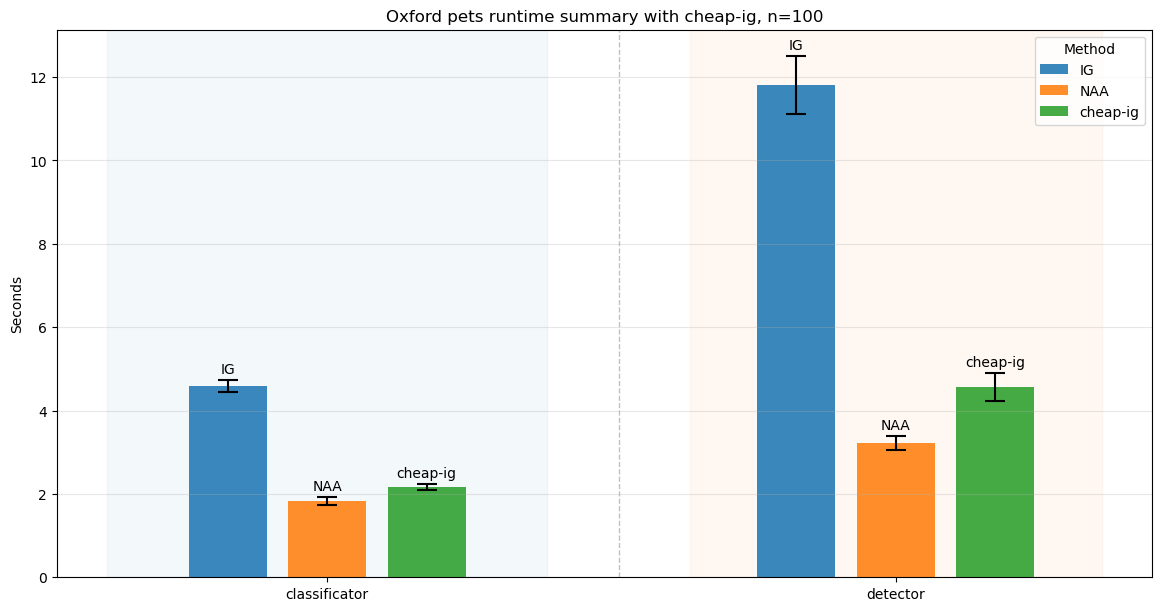

{'aggregate_markdown': '- image_dir=oxford_pets\n- n_images=100\n- n_steps=128\n- target_device=mps\n- cache_root=output/method_timing_cache\n- cheap_ig_classifier_alpha_segment=[0.0, 0.1]\n- cheap_ig_detector_mode=fixed_roi_mean, roi_top_k=3\n- cheap_ig_selection=signed, top_k=5000\n- benchmark cache is external only and not included in method runtime\n\n| Model type | IG | NAA | cheap-ig [0.0,0.1], signed 5000 |\n| --- | ---: | ---: | ---: |\n| classificator | 4.5918 +- 0.1462 | 1.8234 +- 0.1007 | 2.1705 +- 0.0780 |\n| detector | 11.8095 +- 0.6997 | 3.2270 +- 0.1626 | 4.5650 +- 0.3322 |',
 'classifier_cheap_ig_markdown': '- image_dir=oxford_pets\n- n_images=100\n- layer=model.6\n- n_steps=128\n- alpha_segment=[0.0, 0.1]\n- selection_mode=signed\n- selection_top_k=5000\n- target_device=mps\n- cache_root=output/method_timing_cache\n- valid runs: cheap-ig 100/100, abs_error 100/100\n\n| Metric | Value |\n| --- | ---: |\n| runtime | 2.1705 +- 0.0780 |\n| abs_error | 87.9352 +- 36.5472 |\

In [14]:
cheap_ig_classifier_results = benchmark_cheap_ig_classifier_summary(
    image_dir=OXFORD_PETS_DIR,
    limit=OXFORD_PETS_LIMIT,
    layer_name=CLASSIFIER_LAYER,
    n_steps=N_STEPS,
    segment_start=CHEAP_IG_SEGMENT_START,
    segment_end=CHEAP_IG_SEGMENT_END,
    selection_mode=CHEAP_IG_SELECTION_MODE,
    selection_top_k=CHEAP_IG_SELECTION_TOP_K,
    repeats=REPEATS,
    clear_every=CLEAR_EVERY,
    require_mps=CHEAP_IG_REQUIRE_MPS,
)

cheap_ig_detector_results = benchmark_cheap_ig_detector_summary(
    image_dir=OXFORD_PETS_DIR,
    limit=OXFORD_PETS_LIMIT,
    layer_name=DETECTOR_LAYER,
    mode=DETECTOR_MODE,
    roi_top_k=DETECTOR_ROI_TOP_K,
    n_steps=N_STEPS,
    segment_start=CHEAP_IG_SEGMENT_START,
    segment_end=CHEAP_IG_SEGMENT_END,
    selection_mode=CHEAP_IG_SELECTION_MODE,
    selection_top_k=CHEAP_IG_SELECTION_TOP_K,
    repeats=REPEATS,
    clear_every=CLEAR_EVERY,
    require_mps=CHEAP_IG_REQUIRE_MPS,
)

cheap_ig_runtime_markdown = display_cheap_ig_runtime_report(
    oxford_pets_results,
    cheap_ig_classifier_results,
    cheap_ig_detector_results,
)
cheap_ig_runtime_markdown
